## Import Data - Using API Key

In [ ]:
!kaggle datasets download antoreepjana/animals-detection-images-dataset

Dataset URL: https://www.kaggle.com/datasets/antoreepjana/animals-detection-images-dataset
License(s): CC0-1.0
100% 8.92G/8.92G [03:39<00:00, 43.7MB/s]



### Extract Data

In [ ]:
import zipfile

In [ ]:
zip_path = "/content/animals-detection-images-dataset.zip"
extract_path = "/content/animals"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!
Dataset extracted!


### Load Data

In [ ]:
import tensorflow as tf

In [ ]:
train_dir = '/content/animals/train'
test_dir = '/content/animals/test'

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 64

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.class_names)
print("Number of classes:", len(train_ds.class_names))

Found 22566 files belonging to 80 classes.
Found 6505 files belonging to 80 classes.
Classes: ['Bear', 'Brown bear', 'Bull', 'Butterfly', 'Camel', 'Canary', 'Caterpillar', 'Cattle', 'Centipede', 'Cheetah', 'Chicken', 'Crab', 'Crocodile', 'Deer', 'Duck', 'Eagle', 'Elephant', 'Fish', 'Fox', 'Frog', 'Giraffe', 'Goat', 'Goldfish', 'Goose', 'Hamster', 'Harbor seal', 'Hedgehog', 'Hippopotamus', 'Horse', 'Jaguar', 'Jellyfish', 'Kangaroo', 'Koala', 'Ladybug', 'Leopard', 'Lion', 'Lizard', 'Lynx', 'Magpie', 'Monkey', 'Moths and butterflies', 'Mouse', 'Mule', 'Ostrich', 'Otter', 'Owl', 'Panda', 'Parrot', 'Penguin', 'Pig', 'Polar bear', 'Rabbit', 'Raccoon', 'Raven', 'Red panda', 'Rhinoceros', 'Scorpion', 'Sea lion', 'Sea turtle', 'Seahorse', 'Shark', 'Sheep', 'Shrimp', 'Snail', 'Snake', 'Sparrow', 'Spider', 'Squid', 'Squirrel', 'Starfish', 'Swan', 'Tick', 'Tiger', 'Tortoise', 'Turkey', 'Turtle', 'Whale', 'Woodpecker', 'Worm', 'Zebra']
Number of classes: 80


In [ ]:
class_names = train_ds.class_names

In [ ]:
import json

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("Class names saved!")

Class names saved!


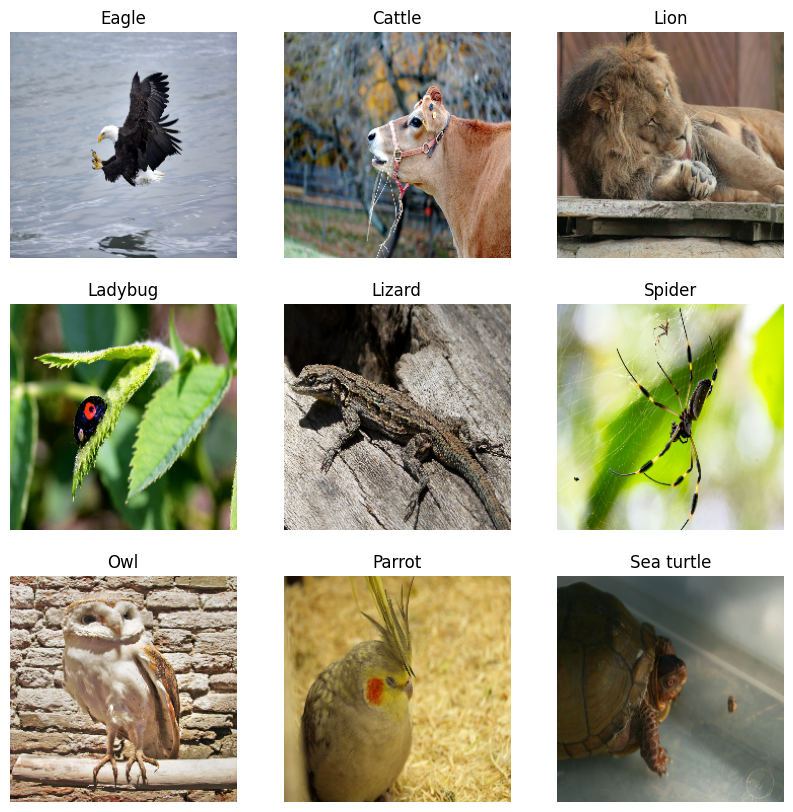

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.savefig('Sample_images')

### Fine Tune Pre-trained Model

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 300s 749ms/step - accuracy: 0.7516 - loss: 1.1299 - val_accuracy: 0.8078 - val_loss: 0.7140
Epoch 2/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 203s 575ms/step - accuracy: 0.8523 - loss: 0.4772 - val_accuracy: 0.8238 - val_loss: 0.5896
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 280s 628ms/step - accuracy: 0.8707 - loss: 0.3955 - val_accuracy: 0.8275 - val_loss: 0.5576
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 202s 573ms/step - accuracy: 0.8825 - loss: 0.3488 - val_accuracy: 0.8281 - val_loss: 0.5459
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 240s 680ms/step - accuracy: 0.8889 - loss: 0.3201 - val_accuracy: 0.8314 - val_loss: 0.5406
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 241s 620ms/step - accuracy: 0.8976 - loss: 0.2944 - val_accuracy: 0.8321 - val_loss: 0.5457
Epoch 7/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 240s 679ms/step - accuracy: 0.9022 - loss: 0.2770 - val_accuracy: 0.8307 - val_loss: 0.5533
Epoch 8/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 239s 678ms/step - accuracy: 0.9055 -

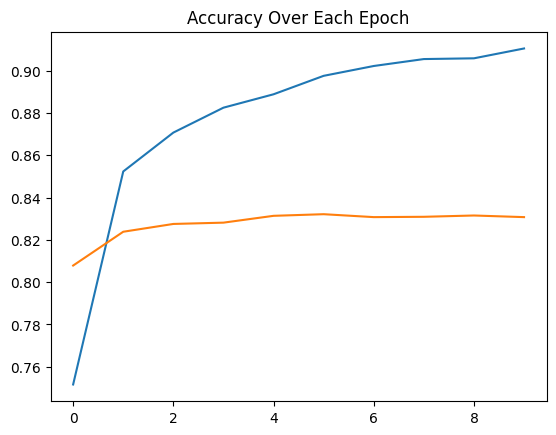

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy Over Each Epoch')
plt.savefig('figures/accuracy')
plt.show()

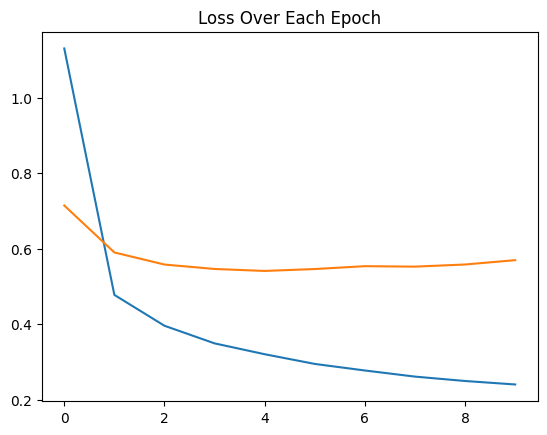

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss Over Each Epoch')
plt.savefig('figures/loss')
plt.show()

In [ ]:
model.save("/content/models/animal_classifier.h5")

print('Model Exported')

Model Exported
